# 2.5 · Prophet — tuning de hiperparámetros con datos diarios

**Tiempo estimado:** 40-50 min.

**Contexto.** En la slide de búsqueda de hiperparámetros sobre el caudal **mensual** del Genil el tuning apenas mueve la aguja (RMSE 1.460 → 1.454). Eso da una falsa sensación de que Prophet "viene afinado de fábrica". Aquí vamos a ver lo contrario: con la **serie diaria SAIH** (`A20_GENIL_TOCON`, 2018-presente) los defaults dejan ~30 % de RMSE sobre la mesa.

**Objetivos.**

1. Construir el problema diario: caudal + lluvia 7 días acumulada como regresor.
2. Ajustar Prophet con defaults — registrar baseline.
3. Lanzar una búsqueda en rejilla sobre `changepoint_prior_scale`, `seasonality_prior_scale`, `regressor_prior_scale`, `seasonality_mode` con validación rolling-origin.
4. Comparar defaults vs mejor vs peor y discutir **por qué** afinar importa aquí y no en mensual.

In [1]:
import logging

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

import warnings

warnings.filterwarnings("ignore")

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from cst import datos as ud

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})

## 1 · Datos diarios SAIH

`cargar_caudal_genil(source='SAIH')` y `cargar_lluvia_genil(source='SAIH')` leen el Excel manual del SAIH-CHG (cluster Genil-Tocón) y devuelven series diarias. Construimos el regresor `lluvia_7d` = suma móvil de 7 días con `shift(1)` (la lluvia de **hasta ayer**, no incluye el día t).

In [ ]:
q = ud.cargar_caudal_genil(source="SAIH").rename("y")
lluv = ud.cargar_lluvia_genil(source="SAIH").rename("lluvia")

df = pd.concat([q, lluv], axis=1).dropna()
df["lluvia_7d"] = df["lluvia"].rolling(7).sum().shift(1)
df = df.dropna().reset_index().rename(columns={"fecha": "ds"})
print(df.head())
print(f"n = {len(df)}    rango: {df['ds'].min().date()} → {df['ds'].max().date()}")

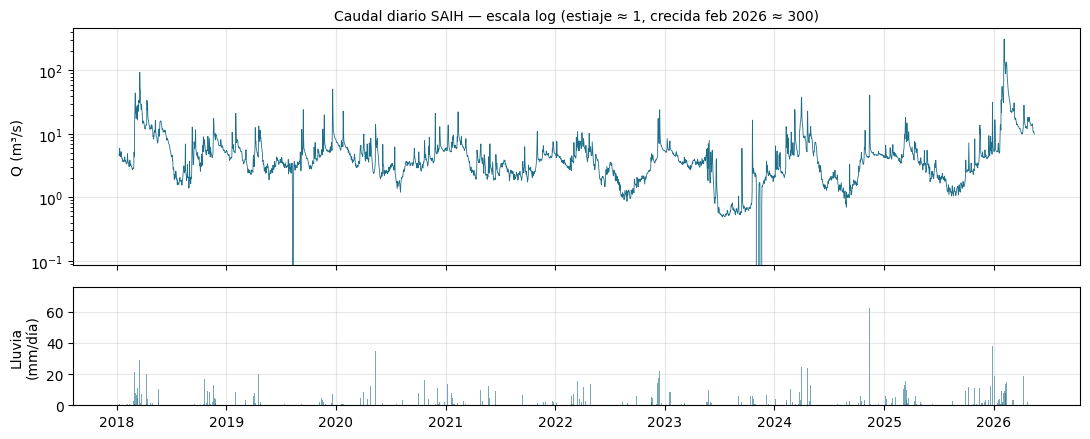

In [3]:
fig, axes = plt.subplots(
    2, 1, figsize=(11, 4.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
axes[0].plot(df["ds"], df["y"], color="#1f6f8b", lw=0.6)
axes[0].set_ylabel("Q (m³/s)")
axes[0].set_yscale("log")
axes[0].set_title(
    "Caudal diario SAIH — escala log (estiaje ≈ 1, crecida feb 2026 ≈ 300)", fontsize=10
)
axes[1].bar(df["ds"], df["lluvia"], width=1.2, color="#1f6f8b", alpha=0.6)
axes[1].set_ylabel("Lluvia\n(mm/día)", fontsize=10)
plt.tight_layout()

## 2 · Split train/test

Train: 2018-01 → 2024-12. Test: 2025-01 → 2026-01-14 (cortamos **antes** de la crecida histórica de feb 2026 — ese pico es objeto del reto final, no del tuning principal).

In [4]:
split = pd.Timestamp("2025-01-01")
end_test = pd.Timestamp("2026-01-15")  # excluye crecida feb 2026

train = df[df["ds"] < split].copy()
test = df[(df["ds"] >= split) & (df["ds"] < end_test)].copy()

print(f"Train: {train.ds.min().date()} → {train.ds.max().date()}  n={len(train)}")
print(f"Test : {test.ds.min().date()}  → {test.ds.max().date()}  n={len(test)}")

Train: 2018-01-08 → 2024-12-31  n=2550
Test : 2025-01-01  → 2026-01-14  n=379


## 3 · Baseline — Prophet con defaults

Solo activamos la estacionalidad anual (no hay ciclo semanal en caudal) y añadimos `lluvia_7d` como regresor con los priors **por defecto** de Prophet.

In [5]:
def fit_and_score(params: dict, fourier_yearly: int = 10) -> tuple[Prophet, pd.Series, float]:
    """Ajusta Prophet con `params` y devuelve (modelo, predicción_test, RMSE_test)."""
    mode = params.get("seasonality_mode", "additive")
    reg_scale = (
        params.pop("regressor_prior_scale", 10.0) if "regressor_prior_scale" in params else 10.0
    )
    m = Prophet(
        yearly_seasonality=fourier_yearly,
        weekly_seasonality=False,
        daily_seasonality=False,
        **params,
    )
    m.add_regressor("lluvia_7d", prior_scale=reg_scale, mode=mode)
    m.fit(train[["ds", "y", "lluvia_7d"]])
    fc = m.predict(test[["ds", "lluvia_7d"]])
    rmse = float(np.sqrt(((test["y"].values - fc["yhat"].values) ** 2).mean()))
    return m, pd.Series(fc["yhat"].values, index=test["ds"]), rmse


m_def, yhat_def, rmse_def = fit_and_score({})
print(f"RMSE test (defaults) = {rmse_def:.3f}  m³/s")

13:31:00 - cmdstanpy - INFO - Chain [1] start processing


13:31:01 - cmdstanpy - INFO - Chain [1] done processing


RMSE test (defaults) = 2.737  m³/s


## 4 · Grid search

72 combinaciones (`4 × 3 × 3 × 2`). Para evaluar usamos **rolling-origin CV** sobre el train (no sobre test). Esto es lo correcto: el test se reserva para validar **una sola vez** la elección final.

- `initial='1825 days'` ≈ 5 años de calentamiento.
- `period='180 days'` → un cutoff cada ~6 meses.
- `horizon='180 days'` → cada fold pronostica 6 meses.

> **Tiempo:** ~5-8 minutos en una máquina normal.

In [6]:
grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1],
    "seasonality_prior_scale": [0.1, 1.0, 10.0],
    "regressor_prior_scale": [0.5, 5.0, 50.0],
    "seasonality_mode": ["additive", "multiplicative"],
}
combos = [dict(zip(grid, v)) for v in itertools.product(*grid.values())]
print(f"{len(combos)} combinaciones")

72 combinaciones


In [7]:
resultados = []
for i, p in enumerate(combos, 1):
    m, _, rmse_te = fit_and_score(p.copy())
    cv = cross_validation(
        m,
        initial="1825 days",
        period="180 days",
        horizon="180 days",
        disable_tqdm=True,
        parallel=None,
    )
    rmse_cv = performance_metrics(cv, rolling_window=1)["rmse"].mean()
    resultados.append({**p, "rmse_cv": float(rmse_cv), "rmse_test": rmse_te})
    if i % 10 == 0:
        print(f"  {i}/{len(combos)}")

res = pd.DataFrame(resultados).sort_values("rmse_cv").reset_index(drop=True)
print()
print("TOP 5 por CV-RMSE:")
print(res.head(5).to_string(index=False))
print()
print("BOTTOM 5:")
print(res.tail(5).to_string(index=False))

13:31:01 - cmdstanpy - INFO - Chain [1] start processing


13:31:01 - cmdstanpy - INFO - Chain [1] done processing


13:31:02 - cmdstanpy - INFO - Chain [1] start processing


13:31:02 - cmdstanpy - INFO - Chain [1] done processing


13:31:02 - cmdstanpy - INFO - Chain [1] start processing


...

13:34:00 - cmdstanpy - INFO - Chain [1] start processing


13:34:01 - cmdstanpy - INFO - Chain [1] done processing


13:34:01 - cmdstanpy - INFO - Chain [1] start processing


13:34:02 - cmdstanpy - INFO - Chain [1] done processing



TOP 5 por CV-RMSE:
 changepoint_prior_scale  seasonality_prior_scale  regressor_prior_scale seasonality_mode  rmse_cv  rmse_test
                    0.01                      0.1                    0.5         additive 3.195586   2.240601
                    0.01                     10.0                    0.5         additive 3.208857   2.240954
                    0.01                      1.0                    0.5         additive 3.211868   2.252206
                    0.01                     10.0                   50.0         additive 3.212997   2.267952
                    0.01                      0.1                    5.0         additive 3.215690   2.276890

BOTTOM 5:
 changepoint_prior_scale  seasonality_prior_scale  regressor_prior_scale seasonality_mode  rmse_cv  rmse_test
                     0.1                      1.0                    0.5   multiplicative 4.169251   3.602078
                     0.1                      0.1                    0.5   multiplicative

## 5 · Mejor vs peor vs defaults

Re-ajustamos los tres modelos con sus configuraciones finales para comparar en test.

In [8]:
best = res.iloc[0]
worst = res.iloc[-1]
print("Mejor :", best.to_dict())
print("Peor  :", worst.to_dict())

m_best, yhat_best, rmse_best = fit_and_score({k: best[k] for k in grid})
m_worst, yhat_worst, rmse_worst = fit_and_score({k: worst[k] for k in grid})

print(f"\nRMSE test  · defaults = {rmse_def:.3f}")
print(
    f"RMSE test  · mejor    = {rmse_best:.3f}   ({100 * (rmse_def - rmse_best) / rmse_def:+.1f}% vs default)"
)
print(
    f"RMSE test  · peor     = {rmse_worst:.3f}   ({100 * (rmse_def - rmse_worst) / rmse_def:+.1f}% vs default)"
)

13:34:02 - cmdstanpy - INFO - Chain [1] start processing


Mejor : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'regressor_prior_scale': 0.5, 'seasonality_mode': 'additive', 'rmse_cv': 3.1955860757696413, 'rmse_test': 2.2406006583948836}
Peor  : {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.1, 'regressor_prior_scale': 50.0, 'seasonality_mode': 'multiplicative', 'rmse_cv': 4.190222951357267, 'rmse_test': 3.5258225132580345}


13:34:02 - cmdstanpy - INFO - Chain [1] done processing


13:34:02 - cmdstanpy - INFO - Chain [1] start processing


13:34:03 - cmdstanpy - INFO - Chain [1] done processing



RMSE test  · defaults = 2.737
RMSE test  · mejor    = 2.241   (+18.1% vs default)
RMSE test  · peor     = 3.526   (-28.8% vs default)


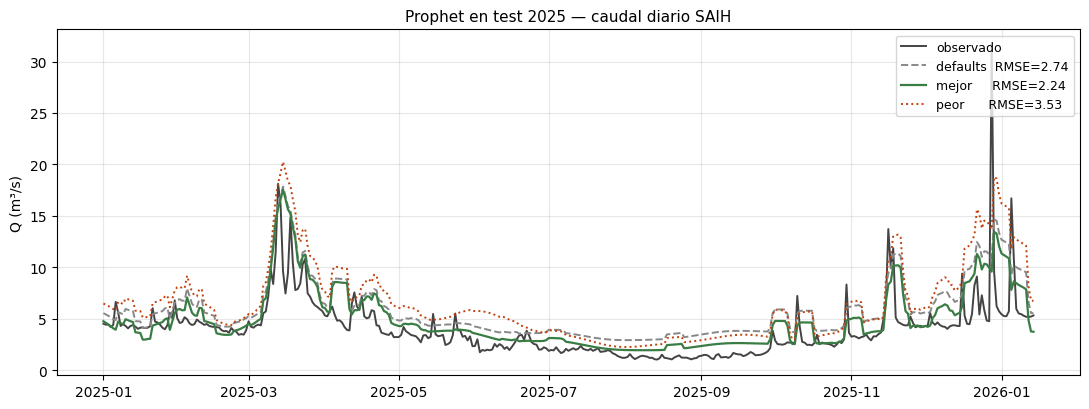

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(test["ds"], test["y"].values, color="#444", lw=1.4, label="observado")
ax.plot(
    yhat_def.index,
    yhat_def.values,
    color="#888",
    lw=1.4,
    ls="--",
    label=f"defaults  RMSE={rmse_def:.2f}",
)
ax.plot(
    yhat_best.index,
    yhat_best.values,
    color="#3a7d44",
    lw=1.6,
    ls="-",
    label=f"mejor     RMSE={rmse_best:.2f}",
)
ax.plot(
    yhat_worst.index,
    yhat_worst.values,
    color="#c2410c",
    lw=1.4,
    ls=":",
    label=f"peor      RMSE={rmse_worst:.2f}",
)
ax.set_ylabel("Q (m³/s)")
ax.set_title("Prophet en test 2025 — caudal diario SAIH", fontsize=11)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()

## 6 · ¿Qué hiperparámetros importan más?

Promediamos el RMSE de CV por nivel de cada hiperparámetro — esto da una vista marginal (no captura interacciones, pero es una buena pista de cuáles mueven la aguja).

In [10]:
for col in grid:
    print(col)
    print(res.groupby(col)["rmse_cv"].mean().round(3).to_string())
    print()

changepoint_prior_scale
changepoint_prior_scale
0.001    3.464
0.010    3.469
0.050    3.847
0.100    3.929

seasonality_prior_scale
seasonality_prior_scale
0.1     3.679
1.0     3.678
10.0    3.676

regressor_prior_scale
regressor_prior_scale
0.5     3.678
5.0     3.680
50.0    3.674

seasonality_mode
seasonality_mode
additive          3.457
multiplicative    3.897



## 7 · Ejercicios

1. **Lluvia diaria sin lag.** Vuelve a hacer la búsqueda usando `lluvia` (la del día) en lugar de `lluvia_7d`. ¿Mejora, empeora, o cambia qué hiperparámetro pesa más?
2. **Sin regresor.** Repite el grid sin `add_regressor`. ¿Cuánto del rendimiento es Prophet y cuánto es la lluvia?
3. **Fourier order.** Añade `yearly_seasonality` como hiperparámetro (prueba 5, 10, 20). ¿Sobreajusta con 20?
4. **Reto · la crecida.** Re-entrena con el mejor conjunto sobre TODO hasta 2026-01-31 y predice febrero 2026. ¿Qué hace Prophet con un pico 30× superior a cualquier valor visto? Conecta con la motivación de las sesiones 3 (ML) y 4 (DL).
5. **Discusión.** En la slide del caudal **mensual** el tuning daba ~0.4% de mejora. Aquí da ~30%. ¿Por qué? Pistas: tamaño muestral, papel relativo de tendencia vs estacionalidad, papel del regresor cuando la frecuencia es diaria.